# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Image mode: L
Image size: (1018, 1022)


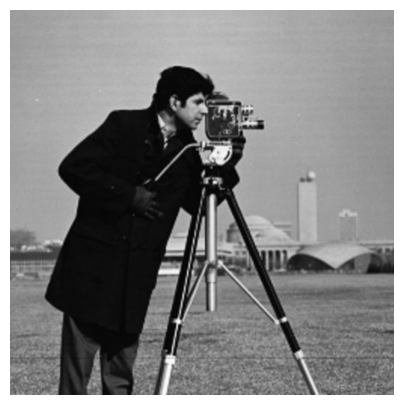

In [2]:
# Load image
image_path = Path('Cameraman.png')
if not image_path.exists():
    image_path = Path('C:/Users/Penguin/Pictures/Screenshots/Cameraman(2).png')

img = Image.open(image_path).convert('L')
print('Image mode:', img.mode)
print('Image size:', img.size)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size

# Scaling factors
scale_x = 2
scale_y = 2
new_size = (width * scale_x, height * scale_y)
print('Original size:', img.size)
print('New size:', new_size)

Original size: (1018, 1022)
New size: (2036, 2044)


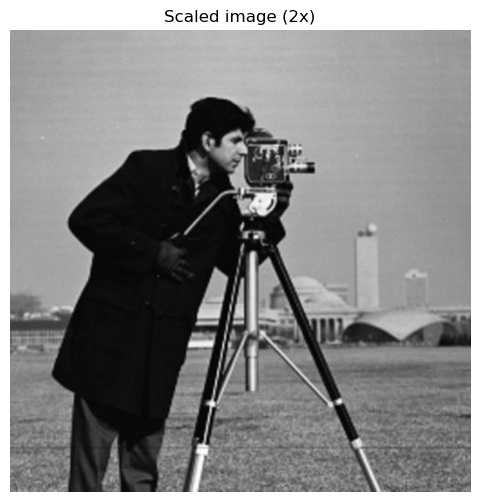

In [4]:
# 1. Increase size (scale x2)
scaled_img = img.resize(new_size, resample=Image.Resampling.LANCZOS)

plt.figure(figsize=(6,6))
plt.imshow(scaled_img, cmap='gray')
plt.title('Scaled image (2x)')
plt.axis('off')
plt.show()

In [5]:
# Save the scaled image and print the sizes
scaled_img.save('task1_1_scaled.jpg')
print('Original size:', img.size)
print('Scaled size:', scaled_img.size)

Original size: (1018, 1022)
Scaled size: (2036, 2044)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
# Non-uniform scale: stretch horizontally only (cx=2, cy=1)
stretched_size = (width * 2, height)
stretched_img = img.resize(stretched_size, resample=Image.Resampling.LANCZOS)
print('Original size:', img.size)
print('Stretched size:', stretched_img.size)

Original size: (1018, 1022)
Stretched size: (2036, 1022)


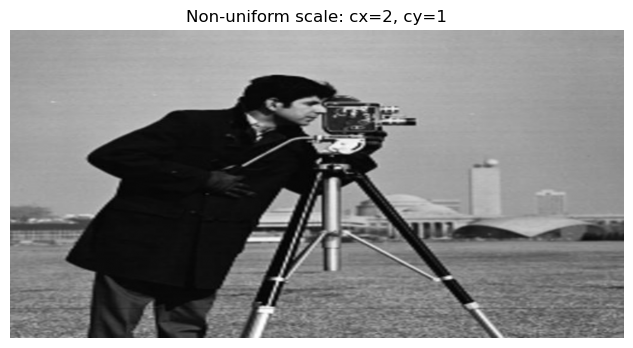

In [7]:
plt.figure(figsize=(8,4))
plt.imshow(stretched_img, cmap='gray')
plt.title('Non-uniform scale: cx=2, cy=1')
plt.axis('off')
plt.show()

In [8]:
stretched_img.save('task1_1_nonuniform.jpg')
print('Saved: task1_1_nonuniform.jpg')

Saved: task1_1_nonuniform.jpg


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

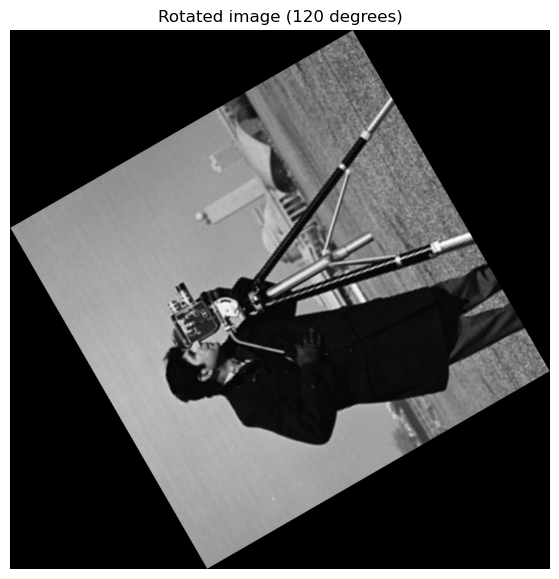

Original size: (1018, 1022)
Rotated size: (1396, 1394)


In [9]:
# 2. Rotate 120 degrees
rotated_img = img.rotate(120, resample=Image.Resampling.BICUBIC, expand=True)
rotated_img.save('task1_2_rotated.jpg')

plt.figure(figsize=(7,7))
plt.imshow(rotated_img, cmap='gray')
plt.title('Rotated image (120 degrees)')
plt.axis('off')
plt.show()

print('Original size:', img.size)
print('Rotated size:', rotated_img.size)

### 3. Shear

In [10]:
# c. Get the image dimensions
width, height = img.size
print('Width:', width, 'Height:', height)

Width: 1018 Height: 1022


In [11]:
# d. Define the shear matrix
shx = 0.5  # X-axis shear factor
shy = 0.0  # Y-axis shear factor

# Forward affine transform: x' = x + shx*y, y' = shy*x + y
# PIL transform() requires the inverse affine mapping.

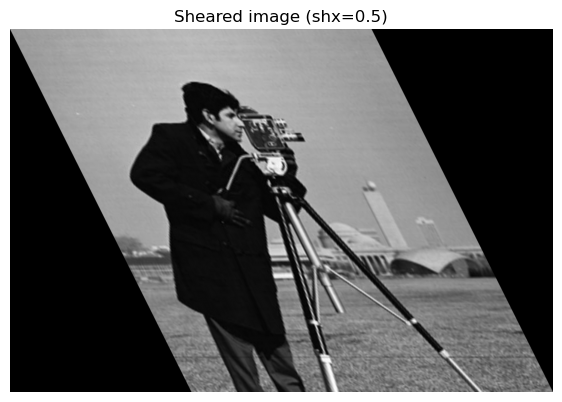

In [12]:
# e. Apply the shear transformation
canvas_width = int(width + abs(shx) * height)
canvas_height = int(height + abs(shy) * width)

# Inverse matrix for x' = x + shx*y and y' = shy*x + y
det = 1 - shx * shy
inv = (1/det, -shx/det, 0, -shy/det, 1/det, 0)

tx = max(0, -shx * height)
ty = max(0, -shy * width)
inv = (inv[0], inv[1], inv[2] + tx, inv[3], inv[4], inv[5] + ty)

sheared_img = img.transform(
    (canvas_width, canvas_height),
    Image.Transform.AFFINE,
    inv,
    resample=Image.Resampling.BICUBIC
)

plt.figure(figsize=(7,5))
plt.imshow(sheared_img, cmap='gray')
plt.title(f'Sheared image (shx={shx})')
plt.axis('off')
plt.show()

In [13]:
# f. Save the sheared image
sheared_img.save('task1_3_sheared.jpg')
print('Saved: task1_3_sheared.jpg')
print('Sheared size:', sheared_img.size)

Saved: task1_3_sheared.jpg
Sheared size: (1529, 1022)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

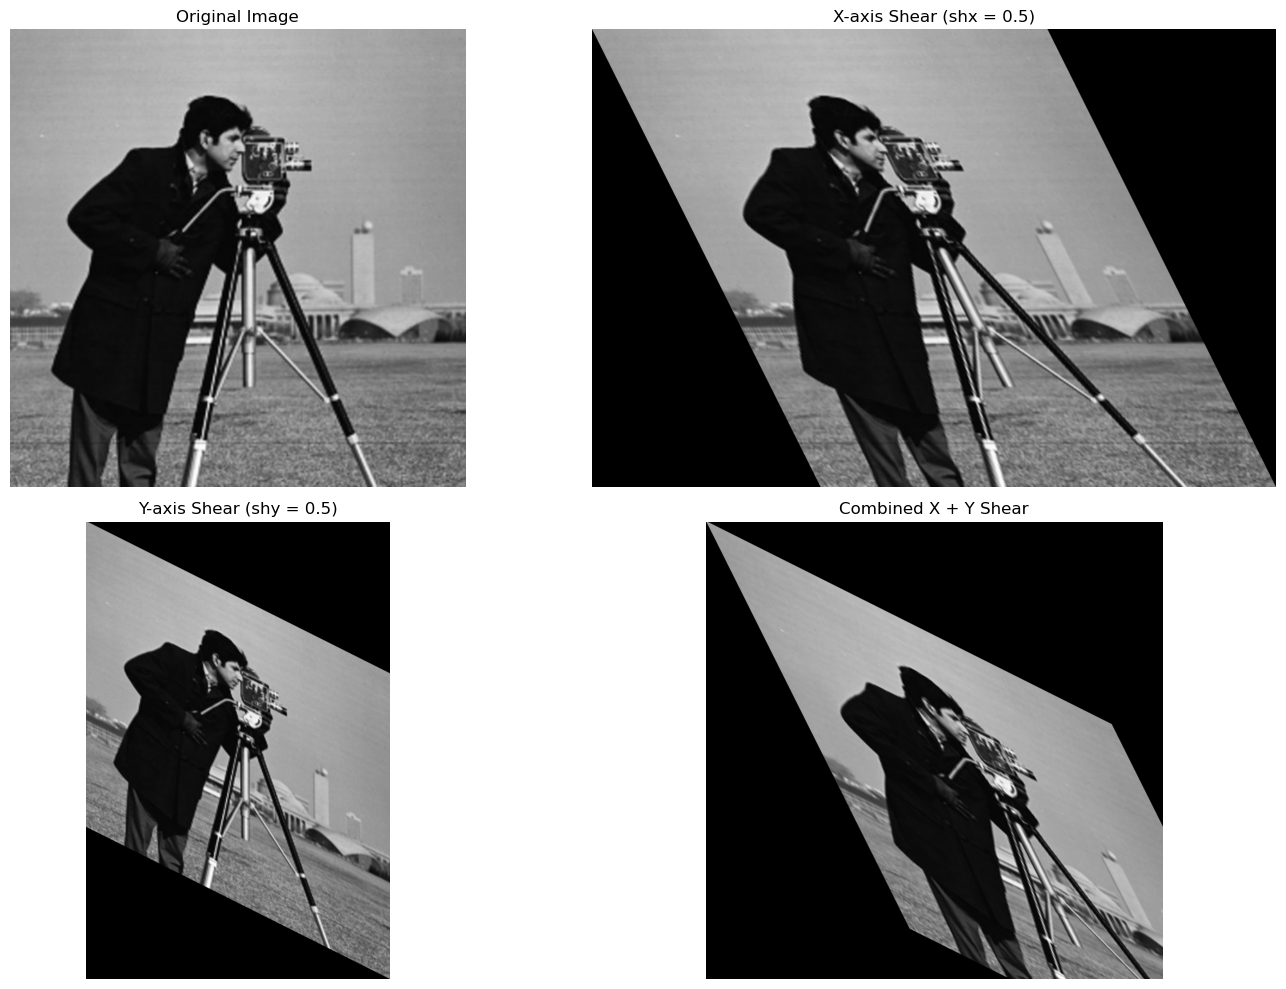

In [14]:
# Experiment 2: X-axis, Y-axis, and Combined Shear

plt.figure(figsize=(15, 10))

# 1. X-axis shear
shx = 0.5
x_shear = img.transform(
    (int(width + abs(shx) * height), height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0)
)

# 2. Y-axis shear
shy = 0.5
y_shear = img.transform(
    (width, int(height + abs(shy) * width)),
    Image.Transform.AFFINE,
    (1, 0, 0, -shy, 1, 0)
)

# 3. Combined X and Y shear
combined_shear = img.transform(
    (int(width + abs(shx) * height), int(height + abs(shy) * width)),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0)
)

# Display Original
plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Display X-axis shear
plt.subplot(2, 2, 2)
plt.imshow(x_shear, cmap="gray")
plt.title("X-axis Shear (shx = 0.5)")
plt.axis("off")

# Display Y-axis shear
plt.subplot(2, 2, 3)
plt.imshow(y_shear, cmap="gray")
plt.title("Y-axis Shear (shy = 0.5)")
plt.axis("off")

# Display Combined shear
plt.subplot(2, 2, 4)
plt.imshow(combined_shear, cmap="gray")
plt.title("Combined X + Y Shear")
plt.axis("off")

plt.tight_layout()
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

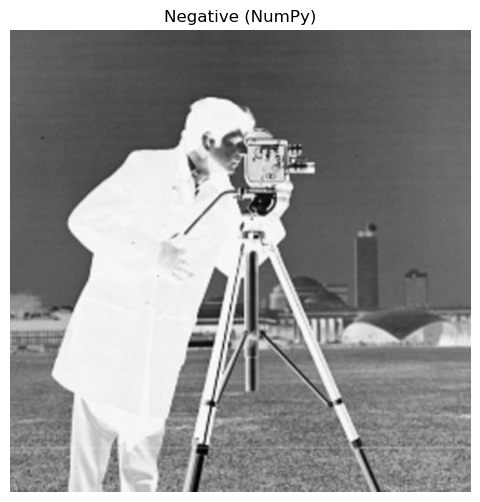

In [15]:
# 1. Negative transformation — Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img_numpy = Image.fromarray(negative_arr.astype(np.uint8))

plt.figure(figsize=(6,6))
plt.imshow(negative_img_numpy, cmap='gray')
plt.title('Negative (NumPy)')
plt.axis('off')
plt.show()

negative_img_numpy.save('task2_1_negative_numpy.jpg')

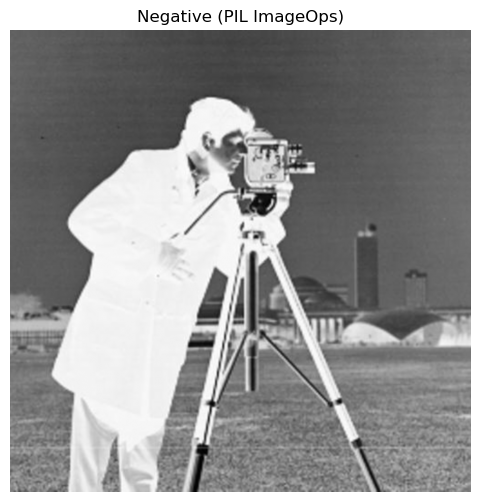

In [16]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)

plt.figure(figsize=(6,6))
plt.imshow(negative_img_pil, cmap='gray')
plt.title('Negative (PIL ImageOps)')
plt.axis('off')
plt.show()

negative_img_pil.save('task2_1_negative_pil.jpg')


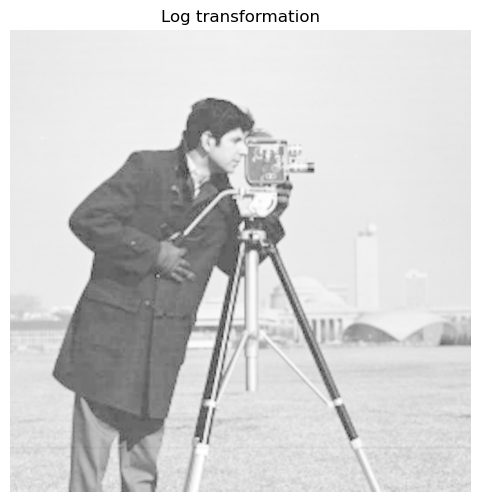

c = 45.98590442833571


In [17]:
# 2. Log transformation: s = c * log(1 + r)
arr_float = np.array(img, dtype=np.float64)
c = 255 / np.log(1 + 255)

# Apply the log transformation
log_transformed_arr = c * np.log(1 + arr_float)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255)
log_img = Image.fromarray(log_transformed_arr.astype(np.uint8))

plt.figure(figsize=(6,6))
plt.imshow(log_img, cmap='gray')
plt.title('Log transformation')
plt.axis('off')
plt.show()

log_img.save('task2_2_log.jpg')
print('c =', c)

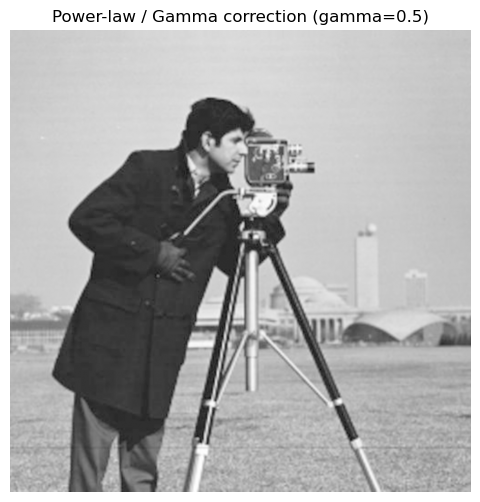

Gamma: 0.5


In [18]:
# 3. Power-law / Gamma correction
# s = c * r^gamma, with r normalized to [0, 1]
gamma = 0.5
normalized = arr_float / 255.0
gamma_transformed_arr = 255 * (normalized ** gamma)
gamma_img = Image.fromarray(np.clip(gamma_transformed_arr, 0, 255).astype(np.uint8))

plt.figure(figsize=(6,6))
plt.imshow(gamma_img, cmap='gray')
plt.title(f'Power-law / Gamma correction (gamma={gamma})')
plt.axis('off')
plt.show()

gamma_img.save('task2_3_gamma.jpg')
print('Gamma:', gamma)


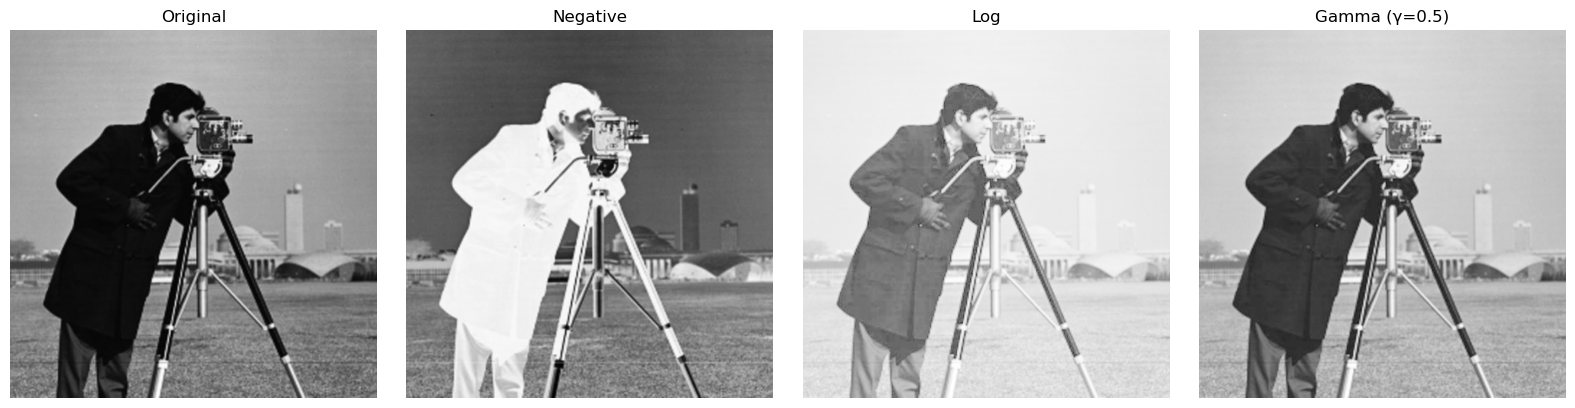

In [19]:
# Compare the original and transformed images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
images = [img, negative_img_pil, log_img, gamma_img]
titles = ['Original', 'Negative', 'Log', f'Gamma (γ={gamma})']

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()